<div style="background:linear-gradient(120deg,#0a2a5c,#1c5aa6);color:#fff;padding:22px 26px;border-radius:12px;border-bottom:5px solid #d49a2a;">
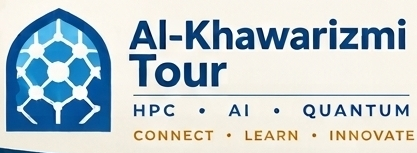
<p style="color:#ffd98e;letter-spacing:.14em;font-size:12px;font-weight:700;margin:12px 0 4px;">AL-KHAWARIZMI TOUR · ONLINE HACKATHON HPC &amp; AI · OCT 3 – NOV 7, 2026 · LECTURE 1 NOTEBOOK</p>
<h1 style="color:#fff;margin:4px 0 6px;border:none;">Data Quality &amp; Preprocessing — Beijing Air Quality · Hands-on &amp; Week-1 Team Challenge</h1>
<p style="color:#e6eef8;margin:0;">Part A: guided demos used during the lecture (slide references in each heading) · Part B: the week-long <b>Air-Quality Data Challenge</b></p>
<p style="color:#ffd98e;margin:10px 0 0;font-style:italic;">Connect · Learn · Innovate — Instructor: Dr. Rafik Borji</p></div>

## How to use this notebook

| Part | When | What |
|---|---|---|
| **A · Guided demos** (A1–A11) | during the 2-hour lecture | each demo matches a slide of the deck / a card of the speaker script |
| **B · Team challenge** (Tasks 1–6 + ★ bonus) | the whole week | fill in the `# TODO` cells, write your report, prepare your pitch |

**Dataset:** *Beijing Multi-Site Air Quality* — UCI Machine Learning Repository, dataset 501. Hourly PM2.5, PM10, SO2, NO2, CO, O3 (µg/m³) and TEMP, PRES, DEWP, RAIN, wind direction `wd`, wind speed `WSPM` at **12 stations**, **1 Mar 2013 – 28 Feb 2017**, **420,768 rows**, with real missing values (NA).
Reference: Zhang, S. et al. (2017) *Cautionary tales on air-quality improvement in Beijing*, Proc. R. Soc. A.

**Data access:** the notebook downloads the archive from UCI (≈ 8 MB) and caches it. If you already have the `PRSA_Data_*.csv` files, put them next to the notebook. Offline, a synthetic stand-in with the same columns is generated so the code still runs.

**Requirements:** Python ≥ 3.9, `numpy`, `pandas`, `matplotlib`, `scikit-learn ≥ 1.2`. Works in Jupyter, VS Code or Google Colab. Tip: on a laptop, run Part A first on `SAMPLE_STATIONS` (4 stations) and switch to all 12 for the challenge.

## 0 · Setup — set your team number first

In [1]:
TEAM_ID = 1065         # LineShine official team ID: it seeds OUR version of the merged dataset
TEAM_NAME = "LineShine"
SEED = 1000 + TEAM_ID

import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": .3})
rng = np.random.default_rng(SEED)
import sklearn; print("scikit-learn", sklearn.__version__, "| team", TEAM_ID)

scikit-learn 1.9.1 | team 1065


---
# Part A · Guided demos
## A1 · Load the 12 station files  *(slides 2 & 13)*

In [2]:
import io, os, glob, ssl, zipfile, urllib.request

STATIONS = ["Aotizhongxin", "Changping", "Dingling", "Dongsi", "Guanyuan", "Gucheng", "Huairou",
            "Nongzhanguan", "Shunyi", "Tiantan", "Wanliu", "Wanshouxigong"]
WD = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE", "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]
POLLUTANTS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
WEATHER = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
KEY = ["station", "year", "month", "day", "hour"]
URL = "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip"
CACHE = "beijing_air_quality_raw.csv.gz"

def _csvs_from_zip(blob):
    """The UCI archive contains a nested zip with one CSV per station -> read them all."""
    frames = []
    with zipfile.ZipFile(io.BytesIO(blob)) as z:
        for name in z.namelist():
            if name.lower().endswith(".zip"):
                frames += _csvs_from_zip(z.read(name))
            elif name.lower().endswith(".csv") and "PRSA_Data" in os.path.basename(name):
                frames.append(pd.read_csv(io.BytesIO(z.read(name))))
    return frames

def _download(url):
    try:
        return urllib.request.urlopen(url, timeout=180).read()
    except Exception:
        return urllib.request.urlopen(url, timeout=180, context=ssl._create_unverified_context()).read()

def synthetic_beijing(seed=0):
    """Offline stand-in with the same columns, 12 stations, seasonal/diurnal cycles and runs of missing values.
    Used ONLY if neither local files nor the UCI download are available."""
    r = np.random.default_rng(seed)
    t = pd.date_range("2013-03-01 00:00", "2017-02-28 23:00", freq="h")
    n, doy, hr = len(t), t.dayofyear.values, t.hour.values
    season = np.cos(2 * np.pi * (doy - 15) / 365.25)                 # +1 in mid-January (heating season)
    e = r.normal(0, 1, n); z = np.zeros(n)
    for i in range(1, n):                                            # regional stagnation index, AR(1)
        z[i] = 0.985 * z[i - 1] + 0.17 * e[i]
    frames = []
    for k, st in enumerate(STATIONS):
        urb = 1.0 if st in ["Dongsi", "Guanyuan", "Gucheng", "Nongzhanguan", "Tiantan", "Wanshouxigong", "Aotizhongxin", "Wanliu"] else 0.0
        TEMP = 13 - 15 * season + 4 * np.sin(2 * np.pi * (hr - 9) / 24) + r.normal(0, 2, n) - (1 - urb)
        DEWP = TEMP - np.clip(r.gamma(2, 4, n) - 3 * z, 0.5, 35)
        PRES = 1012 + 12 * season + r.normal(0, 3, n)
        WSPM = np.clip(r.gamma(2, 0.9, n) - 0.4 * z, 0, None)
        ang = (np.where(z < 0, 315, 180) + r.normal(0, 50, n)) % 360
        wd = np.array(WD)[np.round(ang / 22.5).astype(int) % 16]
        RAIN = np.where(r.random(n) < 0.03 * (1 - season), r.exponential(1.5, n), 0.0)
        logpm = 3.8 + 0.35 * season + 0.9 * z + 0.15 * urb + 0.2 * np.cos(2 * np.pi * (hr - 22) / 24) - 0.15 * WSPM + r.normal(0, .25, n)
        PM25 = np.clip(np.exp(logpm), 3, 900)
        PM10 = PM25 * (1.15 + r.gamma(2, 0.2, n))
        CO = np.clip(300 + 11 * PM25 * (1 + .3 * season) + r.normal(0, 150, n), 100, None)
        NO2 = np.clip(20 + .35 * PM25 ** .8 + 10 * urb + r.normal(0, 8, n), 2, None)
        SO2 = np.clip(3 + 25 * np.clip(season, 0, None) * np.exp(.5 * z) + r.normal(0, 3, n), 2, None)
        O3 = np.clip(10 + 60 * (1 - season) / 2 * 2 * np.clip(np.sin(2 * np.pi * (hr - 8) / 24), 0, None) - .2 * NO2 + r.normal(0, 10, n), 2, None)
        f = pd.DataFrame({"No": np.arange(1, n + 1), "year": t.year, "month": t.month, "day": t.day, "hour": hr,
                          "PM2.5": PM25, "PM10": PM10, "SO2": SO2, "NO2": NO2, "CO": CO, "O3": O3,
                          "TEMP": TEMP, "PRES": PRES, "DEWP": DEWP, "RAIN": RAIN, "wd": wd, "WSPM": WSPM, "station": st}).round(1)
        for c in POLLUTANTS + WEATHER + ["wd"]:                       # runs of missing values
            for s0 in r.choice(n, 25, replace=False):
                f.loc[s0:s0 + int(r.geometric(0.08)), c] = np.nan
        frames.append(f)
    return frames

def load_beijing():
    local = sorted(glob.glob("../data/raw/PRSA_Data_*.csv")) or sorted(glob.glob("**/PRSA_Data_*.csv", recursive=True))
    if local:
        frames = [pd.read_csv(f) for f in local]; src = f"{len(local)} local station files"
    elif os.path.exists(CACHE):
        return pd.read_csv(CACHE)
    else:
        try:
            frames = _csvs_from_zip(_download(URL)); src = "UCI download"
        except Exception as e:
            print("UCI not reachable (", type(e).__name__, ")"); frames = []
        if not frames:
            frames = synthetic_beijing(); src = "SYNTHETIC offline stand-in"
    df = pd.concat(frames, ignore_index=True)
    if src == "UCI download":
        df.to_csv(CACHE, index=False)
    print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns from {src}")
    return df

raw = load_beijing()
assert raw["station"].nunique() == 12 and len(raw) == 420_768, "not the real UCI data: check ../data/raw"
raw["datetime"] = pd.to_datetime(raw[["year", "month", "day", "hour"]])
raw.head()

Loaded 420,768 rows x 18 columns from 12 local station files


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


## A2 · The scenario: a careless merge + an untouched final year  *(slides 27 & 32)*
* **Test year** = 1 Mar 2016 – 28 Feb 2017 (the real data, untouched) — used **only in Task 6**.
* **Training years** = 1 Mar 2013 – 29 Feb 2016 → turned into your team's *merged export* with realistic merge errors.

In [3]:
SPLIT = pd.Timestamp("2016-03-01")
train_raw = raw[raw["datetime"] < SPLIT].reset_index(drop=True)
test_year = raw[raw["datetime"] >= SPLIT].reset_index(drop=True)
print(f"training years: {len(train_raw):,} rows | test year: {len(test_year):,} rows")

training years: 315,648 rows | test year: 105,120 rows


## A3 · Generate your team's merged export
The function reproduces problems of a careless multi-station merge. **Treat it as a black box during the challenge** — your job is to *discover* the problems from the data.

In [4]:
def make_dirty(df, seed):
    r = np.random.default_rng(seed)
    d = df.drop(columns=["datetime"]).copy()
    n = len(d)
    st_unit, st_tz, st_stuck = r.choice(STATIONS, 3, replace=False)
    # 1) consistency: station-name variants and lower-case wind directions
    v = r.random(n)
    d.loc[v < .05, "station"] = d.loc[v < .05, "station"].str.upper()
    d.loc[(v >= .05) & (v < .10), "station"] = d.loc[(v >= .05) & (v < .10), "station"].str.lower() + " "
    w = r.random(n) < .02
    d.loc[w, "wd"] = d.loc[w, "wd"].str.lower()
    stn = d["station"].str.strip().str.title()
    # 2) accuracy: one station exported CO in mg/m3 during 2014
    m = (stn == st_unit) & (d["year"] == 2014)
    d.loc[m, "CO"] = d.loc[m, "CO"] / 1000
    # 3) timeliness: one station exported in UTC during 2015 (8 h behind Beijing time)
    m = (stn == st_tz) & (d["year"] == 2015)
    dt = pd.to_datetime(d.loc[m, ["year", "month", "day", "hour"]]) - pd.Timedelta(hours=8)
    d.loc[m, "year"], d.loc[m, "month"], d.loc[m, "day"], d.loc[m, "hour"] = dt.dt.year, dt.dt.month, dt.dt.day, dt.dt.hour
    # 4) validity: stuck PM2.5 sensor (flat lines), sentinel codes, PM2.5/PM10 column swap
    idx = np.flatnonzero((stn == st_stuck).values)
    for s0 in r.choice(idx[:-80], 8, replace=False):
        L = int(r.integers(24, 73)); rows = d.index[s0:s0 + L]
        d.loc[rows, "PM2.5"] = d.loc[rows[0], "PM2.5"]
    for c in ["TEMP", "PRES"]:
        d.loc[r.random(n) < .002, c] = -999
    sw = r.random(n) < .003
    d.loc[sw, ["PM2.5", "PM10"]] = d.loc[sw, ["PM10", "PM2.5"]].values
    # 5) completeness: extra random logger drop-outs in NO2
    d.loc[r.random(n) < .03, "NO2"] = np.nan
    # 6) uniqueness: one station-month re-uploaded (slightly different O3) + scattered exact duplicates
    s_dup = r.choice(STATIONS); y_dup, m_dup = 2014, int(r.integers(1, 13))
    re = d[(stn == s_dup) & (d["year"] == y_dup) & (d["month"] == m_dup)].copy()
    re["O3"] = re["O3"] + 1
    d = pd.concat([d, re, d.sample(frac=.005, random_state=seed)], ignore_index=True)
    return d.sample(frac=1, random_state=seed).reset_index(drop=True)

dirty = make_dirty(train_raw, SEED)
dirty.to_csv(f"beijing_merged_team{TEAM_ID}.csv.gz", index=False)
print(f"merged export: {dirty.shape[0]:,} rows -> beijing_merged_team{TEAM_ID}.csv.gz")
dirty.head()

merged export: 317,970 rows -> beijing_merged_team1065.csv.gz


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,18617,2015,4,15,16,NaN,NaN,24.0,77.0,NaN,120.0,23.9,990.3,6.2,0.0,SSE,1.5,Aotizhongxin
1,24615,2015,12,21,14,203.0,203.0,34.0,109.0,3200.0,9.0,4.1,1021.8,-4.4,0.0,NNE,1.6,Dongsi
2,3530,2013,7,26,1,3.0,156.0,13.0,71.0,2100.0,52.0,26.7,995.5,20.1,0.0,NNE,0.7,Gucheng
3,4541,2013,9,6,4,52.0,42.0,6.0,24.0,1200.0,30.0,18.6,1007.3,15.8,0.0,SSE,0.9,Changping
4,223,2013,3,10,6,14.0,38.0,11.0,71.0,1000.0,69.0,-2.0,1022.5,-11.8,0.0,NW,0.0,Wanliu


## A4 · First look  *(slides 11, 13 & 14)*

In [5]:
df = dirty.copy()
print("shape:", df.shape, "\n")
print(df.dtypes, "\n")
print("fraction missing:\n", df.isna().mean().round(4).sort_values(ascending=False), "\n")
print("duplicate station-hours:", df.duplicated(subset=KEY).sum())
print("station labels:", df["station"].nunique(), "distinct (expected 12)")

shape: (317970, 18) 

No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd             str
WSPM       float64
station        str
dtype: object 

fraction missing:
 NO2        0.0595
CO         0.0572
O3         0.0322
SO2        0.0221
PM2.5      0.0201
PM10       0.0146
wd         0.0021
RAIN       0.0006
DEWP       0.0006
PRES       0.0006
WSPM       0.0006
TEMP       0.0006
year       0.0000
No         0.0000
day        0.0000
month      0.0000
hour       0.0000
station    0.0000
dtype: float64 

duplicate station-hours: 2330
station labels: 36 distinct (expected 12)


In [6]:
# mean vs median per station -> skew; min / max -> impossible values
df.groupby(df["station"].str.strip().str.title())[["PM2.5", "CO", "TEMP", "PRES"]].agg(["mean", "median", "min", "max"]).round(1)

PM2.5                         CO                          TEMP  \
               mean median  min    max    mean  median    min      max  mean   
station                                                                        
Aotizhongxin   83.7   60.0  3.0  898.0  1273.5   900.0  100.0  10000.0  11.7   
Changping      72.6   48.0  2.0  882.0  1146.0   800.0  100.0  10000.0  11.6   
Dingling       66.8   41.0  3.0  881.0   907.2   600.0  100.0   9400.0  11.6   
Dongsi         85.7   61.0  3.0  737.0  1338.5  1000.0  100.0  10000.0  11.5   
Guanyuan       82.8   60.0  3.0  680.0  1289.9   900.0  100.0  10000.0  11.3   
Gucheng        83.8   61.0  2.0  770.0  1353.4  1000.0  100.0   9900.0  11.8   
Huairou        71.2   48.0  2.0  762.0  1035.2   800.0  100.0  10000.0  10.2   
Nongzhanguan   85.4   60.0  3.0  844.0   887.1   500.0    0.1  10000.0  11.5   
Shunyi         80.2   56.0  3.0  941.0  1187.7   900.0  100.0  10000.0  10.8   
Tiantan        83.1   60.0  3.0  821.0  1311.2  1000.0  100.0  10000.0  11.8   
Wanliu         85.3   61.0  3.0  957.0  1335.2   900.0  100.0  10000.0  11.3   
Wanshouxigong  84.8   61.0  3.0  999.0  1396.6  1000.0  100.0   9800.0  11.7   

                                     PRES                         
              median    min   max    mean  median    min     max  
station                                                           
Aotizhongxin    14.4 -999.0  40.5  1007.5  1011.2 -999.0  1042.0  
Changping       14.6 -999.0  41.4  1003.7  1007.5 -999.0  1036.5  
Dingling        14.6 -999.0  41.4  1003.6  1007.5 -999.0  1036.5  
Dongsi          14.5 -999.0  41.1  1007.9  1012.2 -999.0  1042.0  
Guanyuan        14.4 -999.0  40.5  1006.5  1011.2 -999.0  1042.0  
Gucheng         14.8 -999.0  41.6  1004.9  1008.6 -999.0  1038.1  
Huairou         13.4 -999.0  40.3  1003.8  1007.3 -999.0  1036.5  
Nongzhanguan    14.5 -999.0  41.1  1008.4  1012.3 -999.0  1042.0  
Shunyi          14.2 -999.0  40.6  1007.9  1012.7 -999.0  1042.8  
Tiantan         14.2 -999.0  41.1  1007.8  1012.4 -999.0  1042.0  
Wanliu          14.2 -999.0  40.5  1006.7  1010.8 -999.0  1040.3  
Wanshouxigong   14.7 -999.0  40.6  1007.3  1010.6 -999.0  1042.0

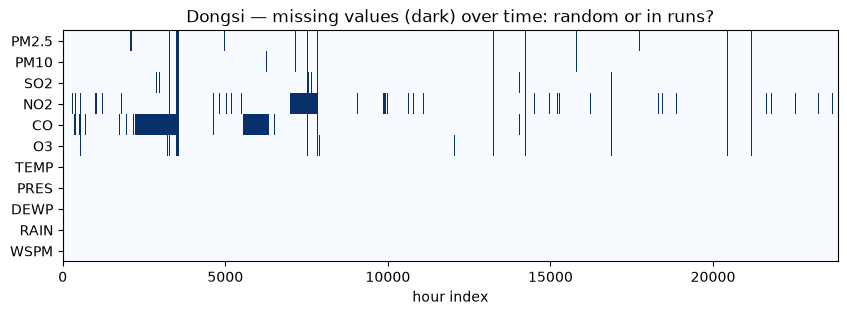

In [7]:
# missing-value matrix for one station (rows = hours in time order)
one = df[df["station"] == "Dongsi"].sort_values(["year", "month", "day", "hour"])
plt.figure(figsize=(10, 3))
plt.imshow(one[POLLUTANTS + WEATHER].isna().values.T, aspect="auto", interpolation="nearest", cmap="Blues")
plt.yticks(range(len(POLLUTANTS + WEATHER)), POLLUTANTS + WEATHER); plt.xlabel("hour index"); plt.grid(False)
plt.title("Dongsi — missing values (dark) over time: random or in runs?"); plt.show()

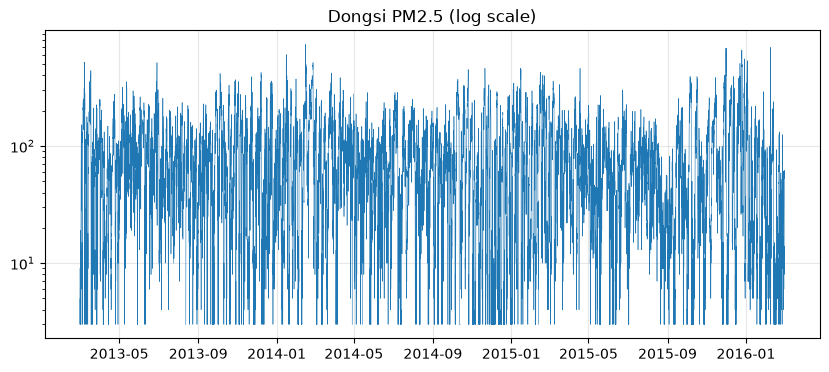

In [8]:
# the single most useful plot: a time series per station
one_dt = pd.to_datetime(one[["year", "month", "day", "hour"]])
plt.plot(one_dt, one["PM2.5"], lw=.4); plt.yscale("log"); plt.title("Dongsi PM2.5 (log scale)"); plt.show()

## A5 · Consistency: canonical labels  *(slide 21)*

In [9]:
print(df["station"].value_counts().head(15))
canon = df["station"].str.strip().str.title()
print("\nafter strip + title:", canon.nunique(), "stations")
print("wind directions:", sorted(df["wd"].dropna().unique()))

station
Tiantan          24340
Dongsi           23836
Wanliu           23813
Changping        23808
Dingling         23806
Huairou          23793
Nongzhanguan     23788
Aotizhongxin     23787
Wanshouxigong    23774
Shunyi           23772
Gucheng          23720
Guanyuan         23710
TIANTAN           1420
tiantan           1410
SHUNYI            1384
Name: count, dtype: int64

after strip + title: 12 stations
wind directions: ['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE', 'SSW', 'SW', 'W', 'WNW', 'WSW', 'e', 'ene', 'ese', 'n', 'ne', 'nne', 'nnw', 'nw', 's', 'se', 'sse', 'ssw', 'sw', 'w', 'wnw', 'wsw']


## A6 · Outliers, stuck sensors and physics checks  *(slides 19 & 20)*

In [10]:
num = df.copy()
checks = {
    "PM2.5 > PM10 (impossible)": int((num["PM2.5"] > num["PM10"]).sum()),
    "negative concentrations":   int((num[POLLUTANTS] < 0).sum().sum()),
    "sentinel -999 codes":       int((num[POLLUTANTS + WEATHER] == -999).sum().sum()),
    "PRES outside 950-1060 hPa": int(((num["PRES"] < 950) | (num["PRES"] > 1060)).sum()),
}
pd.Series(checks, name="rows")

PM2.5 > PM10 (impossible)    22039
negative concentrations          0
sentinel -999 codes           1316
PRES outside 950-1060 hPa      684
Name: rows, dtype: int64

In [11]:
def hampel_flags(s, window=25, k=3.0):
    med = s.rolling(window, center=True, min_periods=5).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=5).median()
    return (s - med).abs() > k * 1.4826 * mad

def stuck_flags(s, hours=12):
    return s.rolling(hours).std() == 0

res = {}
for st, g in df.assign(station=canon).sort_values(["year", "month", "day", "hour"]).groupby("station"):
    res[st] = {"Hampel spikes": int(hampel_flags(g["PM2.5"]).sum()), "stuck >= 12 h": int(stuck_flags(g["PM2.5"]).sum())}
pd.DataFrame(res).T.sort_values("stuck >= 12 h", ascending=False)

,Hampel spikes,stuck >= 12 h
Changping,1239,192
Wanshouxigong,1130,23
Huairou,1339,10
Nongzhanguan,1142,4
Aotizhongxin,1175,1
Dingling,1539,0
Dongsi,1248,0
Gucheng,1240,0
Guanyuan,1101,0
Shunyi,1172,0


## A7 · Imputation study — single hours vs 24-hour gaps  *(slide 18)*
We hide values we **know** (clean reference = the original training years, demo only) and measure the RMSE of each imputer.

In [12]:
from sklearn.impute import KNNImputer
piv = train_raw.pivot_table(index="datetime", columns="station", values="NO2")   # hours x stations
target_st = "Dongsi"
truth = piv[target_st]
known = np.flatnonzero(truth.notna().values)

def make_mask(kind):
    m = np.zeros(len(truth), bool)
    if kind == "single hours":
        m[rng.choice(known, len(known) // 10, replace=False)] = True
    else:                                                    # 24-h blocks
        for s0 in rng.choice(known[:-30], 150, replace=False):
            m[s0:s0 + 24] = True
        m &= truth.notna().values
    return m

def evaluate(mask):
    s = truth.mask(mask)
    others = piv.drop(columns=target_st)
    nb = others.mean(axis=1)
    cand = {
        "mean": s.fillna(s.mean()),
        "median": s.fillna(s.median()),
        "time interpolation": s.interpolate(method="time", limit_direction="both"),
        "neighbour stations": s.fillna(nb + (s - nb).mean()),
        "KNN across stations": pd.Series(KNNImputer(n_neighbors=5).fit_transform(piv.assign(**{target_st: s}))[:, list(piv.columns).index(target_st)], index=s.index),
    }
    return {k: np.sqrt(np.mean((v.fillna(s.mean()).values[mask] - truth.values[mask]) ** 2)) for k, v in cand.items()}

t0 = time.perf_counter()
study = pd.DataFrame({kind: evaluate(make_mask(kind)) for kind in ["single hours", "24-h blocks"]}).round(2)
print(f"({time.perf_counter() - t0:.1f} s)  RMSE of NO2 in µg/m³ — lower is better")
study

(24.8 s)  RMSE of NO2 in µg/m³ — lower is better


,single hours,24-h blocks
mean,33.28,32.38
median,33.88,33.04
time interpolation,7.29,29.49
neighbour stations,13.76,13.17
KNN across stations,9.21,9.81


## A8 · Skewness and transformations  *(slides 12 & 25)*

skewness raw:
 PM2.5    1.93
SO2      2.74
CO       2.45
NO2      1.03
O3       1.75
WSPM     1.67
dtype: float64

skewness after log1p:
 PM2.5   -0.33
SO2      0.42
CO      -0.00
NO2     -0.72
O3      -0.59
WSPM     0.29
dtype: float64


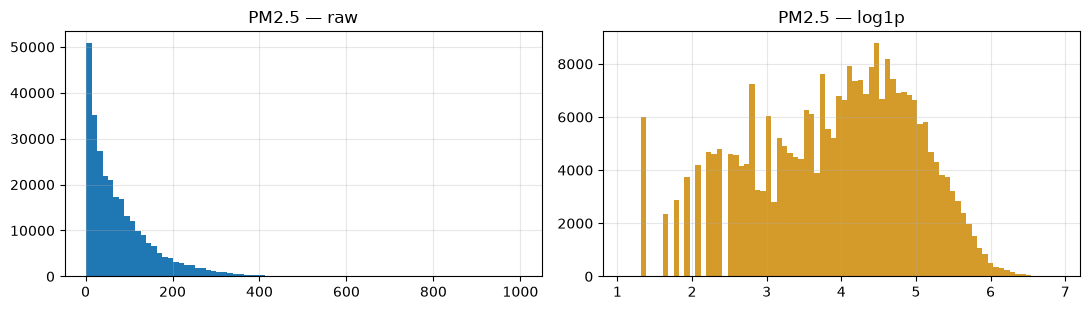

In [13]:
from sklearn.preprocessing import PowerTransformer
vals = train_raw[["PM2.5", "SO2", "CO", "NO2", "O3", "WSPM"]].dropna()
print("skewness raw:\n", vals.skew().round(2))
print("\nskewness after log1p:\n", np.log1p(vals).skew().round(2))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(vals["PM2.5"], bins=80); ax[0].set_title("PM2.5 — raw")
ax[1].hist(np.log1p(vals["PM2.5"]), bins=80, color="#d49a2a"); ax[1].set_title("PM2.5 — log1p")
plt.tight_layout(); plt.show()

## A9 · Multicollinearity — VIF  *(slide 22)*

In [14]:
def vif(frame):
    X = (frame - frame.mean()) / frame.std()
    out = {}
    for c in X.columns:
        Aa = np.column_stack([np.ones(len(X)), X.drop(columns=c).values])
        coef, *_ = np.linalg.lstsq(Aa, X[c].values, rcond=None)
        resid = X[c].values - Aa @ coef
        out[c] = 1 / max(1 - (1 - (resid ** 2).sum() / ((X[c] - X[c].mean()) ** 2).sum()), 1e-12)
    return pd.Series(out, name="VIF").sort_values(ascending=False).round(2)

vif(train_raw[["SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "WSPM"]].dropna().sample(50_000, random_state=0))

TEMP    7.83
DEWP    5.75
PRES    3.14
NO2     2.62
CO      2.52
O3      2.23
SO2     1.83
WSPM    1.60
Name: VIF, dtype: float64

## A10 · Leakage demo — random split vs time split  *(slides 27 & 28)*
Same model, same data, two ways of splitting. The random split lets near-identical neighbouring hours sit on both sides.

In [15]:
def add_features(d):
    """Model-ready features: datetime, cyclical time, circular wind direction, dew-point depression."""
    d = d.copy()
    d["datetime"] = pd.to_datetime(d[["year", "month", "day", "hour"]], errors="coerce")
    d["hour_sin"], d["hour_cos"] = np.sin(2 * np.pi * d["hour"] / 24), np.cos(2 * np.pi * d["hour"] / 24)
    d["month_sin"], d["month_cos"] = np.sin(2 * np.pi * d["month"] / 12), np.cos(2 * np.pi * d["month"] / 12)
    d["dow"] = d["datetime"].dt.dayofweek
    ang = d["wd"].map({w: i * 2 * np.pi / 16 for i, w in enumerate(WD)})
    d["wd_sin"], d["wd_cos"] = np.sin(ang), np.cos(ang)
    d["TD_dep"] = d["TEMP"] - d["DEWP"]                      # dew-point depression (humidity)
    d["rain_flag"] = (d["RAIN"] > 0).astype(float).where(d["RAIN"].notna())
    return d

# Virtual PM2.5 sensor: PM10 is deliberately EXCLUDED (same instrument -> down at the same time)
NUM_FEATS = ["SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM", "TD_dep", "rain_flag",
             "hour_sin", "hour_cos", "month_sin", "month_cos", "dow", "wd_sin", "wd_cos"]
CAT_FEATS = ["station"]
TARGET = "PM2.5"

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score

def make_pipeline(model):
    num = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)), ("scale", StandardScaler())])
    cat = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    prep = ColumnTransformer([("num", num, NUM_FEATS), ("cat", cat, CAT_FEATS)], sparse_threshold=0)
    return Pipeline([("prep", prep), ("model", model)])

ref = add_features(train_raw.drop(columns=["datetime"])).dropna(subset=[TARGET]).sort_values("datetime")
ref = ref.iloc[::3]                                   # every 3rd hour keeps the demo fast
X_ref, y_ref = ref[NUM_FEATS + CAT_FEATS], ref[TARGET]
hgb = make_pipeline(HistGradientBoostingRegressor(max_iter=200, random_state=0))
for name, cv in [("random KFold", KFold(5, shuffle=True, random_state=0)), ("TimeSeriesSplit", TimeSeriesSplit(5))]:
    s = cross_val_score(hgb, X_ref, y_ref, cv=cv, scoring="neg_root_mean_squared_error")
    print(f"{name:16s} CV RMSE = {-s.mean():6.2f} ± {s.std():.2f} µg/m³")

random KFold     CV RMSE =  29.72 ± 0.24 µg/m³


TimeSeriesSplit  CV RMSE =  42.72 ± 10.80 µg/m³


## A11 · Template: a leak-free, time-aware pipeline  *(slide 29)*
`make_pipeline` above is the template you adapt in Task 5. Everything that *learns* (imputers, scalers, encoders) lives **inside** it, so it is re-fitted in every fold.

---
# Part B · Week-1 Team Challenge — *The Air-Quality Data Challenge*

<div style="border:2px solid #d49a2a;background:#fbf1dc;border-radius:10px;padding:12px 18px;color:#14203a;">
<b style="color:#8f5f0c;font-size:15px;">Scenario</b><br>The city’s environmental agency merged the exports of its <b>12 monitoring stations</b> (1 Mar 2013 – 29 Feb 2016) for an AI project. On top of the real gaps, the merge introduced errors. Your file <code>beijing_merged_team&lt;N&gt;.csv.gz</code> (created in A3) is your team’s version. <br><b>Goal:</b> deliver a documented, leak-free pipeline for a <b>virtual PM2.5 sensor</b> — estimate PM2.5 from gases, weather, time and station, <b>without PM10</b> (same instrument, down at the same time) — and <b>prove with numbers</b> how much your data work improves it on the untouched test year.</div>

| # | Task | Points |
|---|---|---|
| 1 | Data-quality audit (six dimensions, gap lengths, missingness by station) | 15 |
| 2 | Consistency, validity & timeliness fixes | 15 |
| 3 | Imputation study (≥ 3 imputers incl. one time-aware) | 15 |
| 4 | Outliers: stuck sensors & spikes vs real episodes; transformations | 10 |
| 5 | Leak-free pipeline + `TimeSeriesSplit` CV | 15 |
| 6 | Impact study on the test year | 20 |
| ★ | HPC bonus: parallel per-station cleaning | +10 |
|   | 1-page report + 5-min pitch | 10 |

**Rules:** `test_year` only in Task 6 · justify every decision in one line · keep `SEED` fixed · start from `beijing_merged_team<N>.csv.gz`, not from `train_raw`.

**Suggested plan:** Days 1–2 Task 1 · Days 3–4 Tasks 2–5 · Day 5 Task 6 (+ bonus) · Days 6–7 report & pitch.

**Hint — what kinds of problems to look for:** label variants, a unit mix-up, a time-zone shift, re-uploaded data, stuck sensors, sentinel codes, physically impossible values, extra drop-outs. *Which station, which column, which period? That is for you to find.*

## Task 1 · Data-quality audit (15 pts)

In [16]:
df = pd.read_csv(f"beijing_merged_team{TEAM_ID}.csv.gz")
stn = df["station"].str.strip().str.title()
print(f"merged export: {len(df):,} rows x {df.shape[1]} cols")

# 1a completeness: % missing per column and per station
print("\n1a  % missing per column"); display((df.isna().mean() * 100).round(2).to_frame("% missing").T)
miss_st = (df[POLLUTANTS + WEATHER + ["wd"]].isna().groupby(stn).mean() * 100).round(2)
display(miss_st.style.background_gradient(cmap="Blues", axis=None).format("{:.1f}"))

def gap_lengths(s):
    """lengths (h) of consecutive-NaN runs in a time-ordered series"""
    isn = s.isna().values
    runs, n = [], 0
    for v in isn:
        if v: n += 1
        elif n: runs.append(n); n = 0
    if n: runs.append(n)
    return runs

order = df.assign(station=stn).drop_duplicates(KEY).sort_values(KEY)
gaps = pd.Series([n for _, grp in order.groupby("station") for c in ["PM2.5", "NO2", "CO"] for n in gap_lengths(grp[c])])
bins = pd.cut(gaps, [0, 1, 3, 6, 24, 72, 10_000], labels=["1 h", "2-3 h", "4-6 h", "7-24 h", "1-3 d", "> 3 d"])
gap_tab = pd.DataFrame({"gaps": bins.value_counts().sort_index(),
                        "missing hours": gaps.groupby(bins).sum()})
gap_tab["% of missing hours"] = (100 * gap_tab["missing hours"] / gap_tab["missing hours"].sum()).round(1)
print("\n1a  gap-length distribution (PM2.5, NO2, CO; all stations)"); display(gap_tab)

merged export: 317,970 rows x 18 cols

1a  % missing per column


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
% missing,0.0,0.0,0.0,0.0,0.0,2.01,1.46,2.21,5.95,5.72,3.22,0.06,0.06,0.06,0.06,0.21,0.06,0.0


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd
station,,,,,,,,,,,,
Aotizhongxin,2.8,2.3,3.0,5.8,6.2,5.5,0.0,0.0,0.0,0.0,0.0,0.0
Changping,2.5,1.9,1.8,5.0,5.2,1.9,0.1,0.1,0.1,0.1,0.1,0.3
Dingling,1.9,1.9,2.0,7.0,6.7,2.9,0.1,0.1,0.1,0.1,0.1,0.3
Dongsi,1.4,0.9,1.3,7.6,10.8,1.2,0.0,0.0,0.0,0.0,0.0,0.0
Guanyuan,1.6,1.1,1.4,5.2,5.8,4.0,0.0,0.0,0.0,0.0,0.0,0.0
Gucheng,1.9,1.1,1.6,5.0,4.8,2.4,0.1,0.1,0.1,0.1,0.1,0.5
Huairou,3.1,2.4,3.2,7.7,4.6,3.7,0.1,0.1,0.1,0.1,0.1,0.5
Nongzhanguan,1.8,1.2,1.3,5.1,3.7,1.5,0.0,0.0,0.0,0.0,0.0,0.0
Shunyi,2.2,1.1,3.3,6.6,6.7,2.2,0.1,0.1,0.1,0.1,0.1,0.8



1a  gap-length distribution (PM2.5, NO2, CO; all stations)


,gaps,missing hours,% of missing hours
1 h,13757,13757,31.8
2-3 h,2147,4750,11.0
4-6 h,538,2558,5.9
7-24 h,485,6197,14.3
1-3 d,83,3528,8.1
> 3 d,42,12507,28.9


In [17]:
# 1b uniqueness
dup_key = df.assign(station=stn).duplicated(KEY, keep=False)
dup_exact = df.duplicated(keep="first")
print(f"1b  rows sharing a station-hour: {dup_key.sum():,} | exact duplicate rows: {dup_exact.sum():,}")
near = df.assign(station=stn)[dup_key & ~df.duplicated(keep=False)]
diff_cols = near.groupby(KEY).agg(lambda s: s.nunique() > 1).sum()
print("    columns that differ inside non-identical duplicate groups:", diff_cols[diff_cols > 0].to_dict())
print("    where:", near.groupby(["station", "year", "month"]).size().to_dict())

# 1c validity
val = {"PM2.5 > PM10": int((df["PM2.5"] > df["PM10"]).sum()),
       "negative concentrations": int((df[POLLUTANTS] < 0).sum().sum()),
       "-999 TEMP": int((df["TEMP"] == -999).sum()), "-999 PRES": int((df["PRES"] == -999).sum()),
       "PRES outside 950-1060 hPa (excl. -999)": int(((df["PRES"] != -999) & ((df["PRES"] < 950) | (df["PRES"] > 1060))).sum()),
       "TEMP outside -30..45 °C (excl. -999)": int(((df["TEMP"] != -999) & ((df["TEMP"] < -30) | (df["TEMP"] > 45))).sum())}
print("\n1c  validity:", val)
print("    ratio PM2.5/PM10 where PM2.5 > PM10: median", round((df["PM2.5"] / df["PM10"])[df["PM2.5"] > df["PM10"]].median(), 2))

1b  rows sharing a station-hour: 4,653 | exact duplicate rows: 1,592


    columns that differ inside non-identical duplicate groups: {'No': 8, 'PM2.5': 4, 'PM10': 8, 'SO2': 8, 'NO2': 8, 'CO': 5, 'O3': 731, 'TEMP': 8, 'PRES': 8, 'DEWP': 8, 'wd': 5, 'WSPM': 8}
    where: {('Shunyi', 2014, 12): 16, ('Tiantan', 2014, 3): 1453}

1c  validity: {'PM2.5 > PM10': 22039, 'negative concentrations': 0, '-999 TEMP': 632, '-999 PRES': 684, 'PRES outside 950-1060 hPa (excl. -999)': 0, 'TEMP outside -30..45 °C (excl. -999)': 0}
    ratio PM2.5/PM10 where PM2.5 > PM10: median 1.3


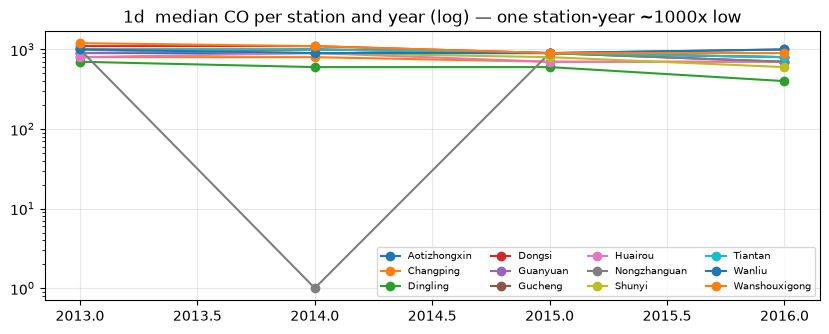

station-years whose median is < 1/100 or > 100x the cross-station median:


,,SO2,NO2,CO,O3
station,year,,,,
Nongzhanguan,2014,1.1579,1.0755,0.0011,1.0


1e  hour of the mean TEMP peak


year,2013,2014,2015,2016
station,,,,
Aotizhongxin,14,14,15,15
Changping,15,14,15,15
Dingling,15,14,14,16
Dongsi,16,14,16,15
Guanyuan,14,16,13,15
Gucheng,14,16,14,14
Huairou,13,15,15,15
Nongzhanguan,14,14,14,15
Shunyi,16,16,8,15


    hour of the mean O3 peak


year,2013,2014,2015,2016
station,,,,
Aotizhongxin,16,16,16,15
Changping,16,16,16,15
Dingling,16,16,16,15
Dongsi,16,16,16,15
Guanyuan,15,15,16,14
Gucheng,16,16,16,14
Huairou,16,16,16,14
Nongzhanguan,15,16,16,15
Shunyi,15,16,7,15


1f  distinct raw station labels: 36 -> ['AOTIZHONGXIN', 'Aotizhongxin', 'CHANGPING', 'Changping', 'DINGLING', 'DONGSI', 'Dingling', 'Dongsi'] ...
    distinct raw wd labels: 32 -> ['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE', 'SSW', 'SW', 'W', 'WNW', 'WSW', 'e', 'ene', 'ese', 'n', 'ne', 'nne', 'nnw', 'nw', 's', 'se', 'sse', 'ssw', 'sw', 'w', 'wnw', 'wsw']


In [18]:
# 1d accuracy: station medians per year on a log scale -> an x1000 unit error stands out
med = df.groupby([stn, "year"])[["SO2", "NO2", "CO", "O3"]].median()
ratio = med / med.groupby("year").transform("median")
fig, ax = plt.subplots(figsize=(10, 3.5))
co = med["CO"].unstack()
for st in co.index: ax.plot(co.columns, co.loc[st], marker="o", label=st)
ax.set_yscale("log"); ax.set_title("1d  median CO per station and year (log) — one station-year ~1000x low"); ax.legend(ncol=4, fontsize=7); plt.show()
print("station-years whose median is < 1/100 or > 100x the cross-station median:")
display(ratio[(ratio < 0.01).any(axis=1) | (ratio > 100).any(axis=1)].round(4))

# 1e timeliness: hour of the mean daily TEMP peak per station and year (expected ~14-16 h Beijing time)
peak = df.groupby([stn, "year", "hour"])["TEMP"].mean().unstack().idxmax(axis=1).unstack()
o3peak = df.groupby([stn, "year", "hour"])["O3"].mean().unstack().idxmax(axis=1).unstack()
print("1e  hour of the mean TEMP peak"); display(peak)
print("    hour of the mean O3 peak"); display(o3peak)

# 1f consistency: raw labels
print("1f  distinct raw station labels:", df["station"].nunique(), "->", sorted(df["station"].unique())[:8], "...")
print("    distinct raw wd labels:", df["wd"].nunique(), "->", sorted(df["wd"].dropna().unique()))

In [19]:
def swap_mask(d):
    """PM2.5 > PM10 is only a *swap* if the PM10 value fits the neighbouring PM2.5 hours better
    (the real data also has ~1 µg/m³ PM2.5 > PM10 differences from instrument noise, which we must keep).
    d must be sorted by station and time."""
    g = d.groupby("station")["PM2.5"]
    nb = (g.shift(1) + g.shift(-1)) / 2
    return (d["PM2.5"] > d["PM10"]) & ((d["PM10"] - nb).abs() < (d["PM2.5"] - nb).abs())

n_swap = int(swap_mask(order.reset_index(drop=True)).sum())
print(f"1c  PM2.5 > PM10: {val['PM2.5 > PM10']:,} rows, of which {n_swap:,} look like column swaps (neighbour test)")

# Issue log — rows are generated from the audit numbers above (no hand-typed counts)
UNIT_ST = ratio["CO"].idxmin()                                    # (station, year) with the x1000 error
TZ_ST = (peak - peak.median()).abs().stack().idxmax()             # (station, year) with the shifted peak
stuck_cnt = {}
for st, g in df.assign(station=stn).drop_duplicates(KEY).sort_values(KEY).groupby("station"):
    stuck_cnt[st] = int(stuck_flags(g["PM2.5"]).sum())
STUCK_ST = max(stuck_cnt, key=stuck_cnt.get)
issue_log = pd.DataFrame(columns=["dimension", "station", "column", "period", "problem", "rows affected", "fix", "justification"])
L = lambda *r: issue_log.loc.__setitem__(len(issue_log), list(r))
L("consistency", "all", "station", "all", "upper / lower-case + trailing-space variants", int((df["station"] != stn).sum()), "strip + title case", "12 physical stations")
L("consistency", "all", "wd", "all", "lower-case wind directions", int(df["wd"].str.islower().sum()), "upper case", "16-point compass is upper case")
L("accuracy", UNIT_ST[0], "CO", str(UNIT_ST[1]), "CO exported in mg/m³ (x1000 low)", int(((stn == UNIT_ST[0]) & (df["year"] == UNIT_ST[1])).sum()), "multiply by 1000", f"median ratio to other stations {ratio['CO'].min():.4f}")
L("timeliness", TZ_ST[0], "year/month/day/hour", str(TZ_ST[1]), f"TEMP peak at {peak.loc[TZ_ST]} h vs ~{int(peak.median().median())} h: UTC export", int(((stn == TZ_ST[0]) & (df["year"] == TZ_ST[1])).sum()), "+8 h (exact: rebuild from row counter `No`)", "diurnal TEMP/O3 peaks realign")
L("validity", "all", "TEMP", "all", "-999 sentinel", val["-999 TEMP"], "NaN", "not a measurement")
L("validity", "all", "PRES", "all", "-999 sentinel", val["-999 PRES"], "NaN", "not a measurement")
L("validity", "all", "PM2.5/PM10", "all", f"PM2.5 > PM10 in {val['PM2.5 > PM10']:,} rows; swap test positive", n_swap, "swap back only those", "swapped value fits neighbour hours; the rest is instrument noise")
L("validity", STUCK_ST, "PM2.5", "several runs", "stuck sensor: constant >= 12 h", stuck_cnt[STUCK_ST], "whole run -> NaN", "real PM2.5 never flat for a day")
L("uniqueness", "all", "all", "scattered", "exact duplicate rows", int(dup_exact.sum()), "drop", "identical re-export")
L("uniqueness", *near.groupby(["station", "year", "month"]).size().idxmax()[:1], "O3", "1 station-month", "month re-uploaded with O3 +1", int(len(near) // 2), "keep the first copy", "1 µg/m³ difference, below sensor precision")
L("completeness", "all", "NO2", "all", f"NO2 missing {df['NO2'].isna().mean():.1%} (others ~2-6%)", int(df["NO2"].isna().sum()), "imputed per gap length (Task 3)", "logger drop-outs")
issue_log

1c  PM2.5 > PM10: 22,039 rows, of which 4,870 look like column swaps (neighbour test)


,dimension,station,column,period,problem,rows affected,fix,justification
0,consistency,all,station,all,upper / lower-case + trailing-space variants,32023,strip + title case,12 physical stations
1,consistency,all,wd,all,lower-case wind directions,6335,upper case,16-point compass is upper case
2,accuracy,Nongzhanguan,CO,2014,CO exported in mg/m³ (x1000 low),8814,multiply by 1000,median ratio to other stations 0.0011
3,timeliness,Shunyi,year/month/day/hour,2015,TEMP peak at 8 h vs ~14 h: UTC export,8800,+8 h (exact: rebuild from row counter `No`),diurnal TEMP/O3 peaks realign
4,validity,all,TEMP,all,-999 sentinel,632,NaN,not a measurement
5,validity,all,PRES,all,-999 sentinel,684,NaN,not a measurement
6,validity,all,PM2.5/PM10,all,"PM2.5 > PM10 in 22,039 rows; swap test positive",4870,swap back only those,swapped value fits neighbour hours; the rest i...
7,validity,Changping,PM2.5,several runs,stuck sensor: constant >= 12 h,171,whole run -> NaN,real PM2.5 never flat for a day
8,uniqueness,all,all,scattered,exact duplicate rows,1592,drop,identical re-export
9,uniqueness,Tiantan,O3,1 station-month,month re-uploaded with O3 +1,734,keep the first copy,"1 µg/m³ difference, below sensor precision"


**✍ Answer & conclusion (Task 1)**

The merged export has **317,970 rows**, where 12 stations × 26,304 h = 315,648 are expected. The audit found 11 issues across all six dimensions (issue log above):

* **Completeness:** NO2 is missing in **6.0 %** of rows and CO in 5.7 %; the other columns are under 3.3 %. **31.8 %** of missing hours are 1-h gaps, but **28.9 %** sit in gaps longer than 3 days, so imputation must depend on gap length.
* **Uniqueness:** **1,592** exact duplicate rows, plus one re-uploaded station-month (**Tiantan, Mar 2014, 734 rows**) where only O3 differs (+1).
* **Validity:** **632** TEMP and **684** PRES `-999` codes. PM2.5 > PM10 occurs in **22,039** rows, but only **4,870** pass the neighbour test for a swap; the rest is real instrument noise.
* **Accuracy:** **Nongzhanguan CO in 2014** has a median **0.0011×** that of the other stations, i.e. it was exported in mg/m³.
* **Timeliness:** **Shunyi in 2015** peaks for TEMP at **8 h** and for O3 at **7 h**, against 14–16 h everywhere else, i.e. a UTC export (−8 h).
* **Consistency:** **36** station labels instead of 12, and **32** wind-direction labels instead of 16.
* **Stuck sensor:** the Changping PM2.5 sensor has flat runs of 24–72 h.

## Task 2 · Consistency, validity & timeliness fixes (15 pts)
Write **one function** `clean_basic(df)` you could apply to next month's export. It should at least: canonicalise `station` and `wd`; fix the unit problem; undo the time-zone shift; set sentinel codes and impossible values to NaN (or repair the swap); flag stuck-sensor runs as NaN; resolve duplicate station-hours; build `datetime`; sort by station and time.

In [20]:
def detect_issues(d):
    """Data-driven detection, so the same code works on next month's export or another team seed."""
    s = d["station"].str.strip().str.title()
    med = d.groupby([s, "year"])["CO"].median()
    rel = med / med.groupby("year").transform("median")
    unit = [k for k, v in rel.items() if v < 0.01]                                    # x1000 too small
    pk = d.groupby([s, "year", "hour"])["TEMP"].mean().unstack().idxmax(axis=1)
    tz = [k for k, v in (pk - pk.groupby(level="year").transform("median")).items() if abs(v) >= 4]
    return {"unit_CO": unit, "tz_shift": tz}

def clean_basic(d, issues=None, stuck_hours=12):
    d = d.copy()
    issues = issues or detect_issues(d)
    # 1 consistency
    d["station"] = d["station"].str.strip().str.title()
    d["wd"] = d["wd"].str.strip().str.upper()
    # 2 accuracy: unit
    for st, yr in issues["unit_CO"]:
        m = (d["station"] == st) & (d["year"] == yr); d.loc[m, "CO"] *= 1000
    # 3 timeliness: undo the UTC shift (exactly via the hourly counter `No` when present, else +8 h)
    dt = pd.to_datetime(d[["year", "month", "day", "hour"]])
    for st, yr in issues["tz_shift"]:
        m = d["station"] == st
        if "No" in d:
            dt[m] = pd.Timestamp("2013-03-01") + pd.to_timedelta(d.loc[m, "No"] - 1, unit="h")
        else:
            m &= d["year"] == yr; dt[m] = dt[m] + pd.Timedelta(hours=8)
    d["datetime"] = dt
    d["year"], d["month"], d["day"], d["hour"] = dt.dt.year, dt.dt.month, dt.dt.day, dt.dt.hour
    # 4 validity: sentinels / impossible values -> NaN, PM2.5/PM10 swap repaired
    d[POLLUTANTS + WEATHER] = d[POLLUTANTS + WEATHER].mask(d[POLLUTANTS + WEATHER] == -999)
    d.loc[~d["PRES"].between(950, 1060), "PRES"] = np.nan
    d.loc[~d["TEMP"].between(-30, 45), "TEMP"] = np.nan
    d[POLLUTANTS] = d[POLLUTANTS].mask(d[POLLUTANTS] < 0)
    # 5 uniqueness: exact duplicates, then one row per station-hour (first copy)
    d = d.drop_duplicates().drop_duplicates(["station", "datetime"], keep="first")
    d = d.sort_values(["station", "datetime"]).reset_index(drop=True)
    sw = swap_mask(d)                                                    # (validity) swap repaired after sorting
    d.loc[sw, ["PM2.5", "PM10"]] = d.loc[sw, ["PM10", "PM2.5"]].values
    # 6 stuck sensor: every PM2.5 run constant for >= stuck_hours -> NaN (whole run, not just its tail)
    g = d.groupby("station")["PM2.5"]
    run_id = (d["PM2.5"] != g.shift()).cumsum()
    run_len = d.groupby(run_id)["PM2.5"].transform("size")
    d.loc[(run_len >= stuck_hours) & d["PM2.5"].notna(), "PM2.5"] = np.nan
    return d.drop(columns=["No"], errors="ignore")

issues = detect_issues(df)
print("detected:", issues)
t0 = time.perf_counter(); df_clean = clean_basic(df, issues); print(f"clean_basic: {time.perf_counter() - t0:.1f} s")
print(f"rows {len(df):,} -> {len(df_clean):,} | stations {df_clean['station'].nunique()} | wd labels {df_clean['wd'].nunique()}")
print("expected rows (12 stations x 26,304 h):", 12 * 26_304, "| duplicate station-hours left:", df_clean.duplicated(["station", "datetime"]).sum())

detected: {'unit_CO': [('Nongzhanguan', 2014)], 'tz_shift': [('Shunyi', 2015)]}


clean_basic: 1.1 s
rows 317,970 -> 315,648 | stations 12 | wd labels 16


expected rows (12 stations x 26,304 h): 315648 | duplicate station-hours left: 0


In [21]:
# verification: the fixes must make the symptoms disappear
pk2 = df_clean.groupby(["station", "year", "hour"])["TEMP"].mean().unstack().idxmax(axis=1).unstack()
co2 = df_clean.groupby(["station", "year"])["CO"].median().unstack()
print("TEMP-peak hour after fix (min..max over station-years):", pk2.values.min(), "..", pk2.values.max())
print("CO median range after fix:", co2.values.min(), "..", co2.values.max())
print("PM2.5 > PM10 left (instrument noise, kept):", int((df_clean["PM2.5"] > df_clean["PM10"]).sum()), "| -999 left:", int((df_clean[POLLUTANTS + WEATHER] == -999).sum().sum()))

TEMP-peak hour after fix (min..max over station-years): 14 .. 15
CO median range after fix: 400.0 .. 1200.0
PM2.5 > PM10 left (instrument noise, kept): 16888 | -999 left: 0


**✍ Answer & conclusion (Task 2)**

`clean_basic` detects every problem **from the data** (`detect_issues`) instead of hard-coding stations, so it works on next month's export or on any team seed. On our file it found `unit_CO = [(Nongzhanguan, 2014)]` and `tz_shift = [(Shunyi, 2015)]`. Verification:

* Rows: 317,970 → **315,648**, exactly 12 × 26,304 h, with **0** duplicate station-hours. There are 12 stations and 16 wind directions.
* The TEMP peak hour is now **14–15 h** for every station-year, and CO medians lie in 400–1,200 µg/m³ for all station-years.
* The time shift is undone **exactly** by rebuilding the timestamp from the hourly counter `No`. `No` agrees with the stated time for every other station. A plain +8 h would leave 8 duplicated hours on 31 Dec 2014 and 8 missing hours on 31 Dec 2015.
* Decisions: sentinels and impossible values → NaN. Swaps are repaired only when the swapped value fits the neighbouring hours. Each whole stuck run becomes NaN, not just its tail. For the re-uploaded month we keep the first copy, since the O3 difference is 1 µg/m³.

## Task 3 · Imputation study (15 pts)
Using **your cleaned data**, extend A7: compare ≥ 3 imputers (at least one time-aware, e.g. limited interpolation, neighbour-station, seasonal-hourly profile) for **two** pollutants, with both single-hour and 24-h masks. Choose a strategy per gap length and justify it.

In [22]:
from sklearn.impute import KNNImputer
rng3 = np.random.default_rng(SEED)

def impute_candidates(piv, col, s):
    others = piv.drop(columns=col)
    nb = others.mean(axis=1)
    offset = (s - nb).mean()
    prof = s.groupby([s.index.month, s.index.hour]).transform("median")
    return {
        "station median": s.fillna(s.median()),
        "time interpolation": s.interpolate(method="time", limit_direction="both"),
        "seasonal-hourly profile": s.fillna(prof),
        "neighbour stations": s.fillna(nb + offset),
        "KNN across stations": pd.Series(KNNImputer(n_neighbors=5).fit_transform(piv.assign(**{col: s}))[:, list(piv.columns).index(col)], index=s.index),
    }

def masks(truth):
    known = np.flatnonzero(truth.notna().values)
    m1 = np.zeros(len(truth), bool); m1[rng3.choice(known, len(known) // 10, replace=False)] = True
    m24 = np.zeros(len(truth), bool)
    for s0 in rng3.choice(known[:-30], 150, replace=False): m24[s0:s0 + 24] = True
    return {"single hours": m1, "24-h blocks": m24 & truth.notna().values}

study = {}
for pol in ["NO2", "CO"]:
    piv = df_clean.pivot_table(index="datetime", columns="station", values=pol)
    for st in ["Dongsi", "Huairou"]:                                  # one urban, one suburban station
        truth = piv[st]
        for kind, m in masks(truth).items():
            cand = impute_candidates(piv, st, truth.mask(m))
            study[(pol, st, kind)] = {k: np.sqrt(np.mean((v.fillna(truth.mask(m).mean()).values[m] - truth.values[m]) ** 2)) for k, v in cand.items()}
study = pd.DataFrame(study).T.round(1)
print("RMSE of hidden known values (µg/m³) — lower is better"); display(study.style.highlight_min(axis=1, color="#c7e9c0"))
best = study.idxmin(axis=1).groupby(level=2).agg(lambda s: s.value_counts().idxmax())
print("winner per gap type:", best.to_dict())

RMSE of hidden known values (µg/m³) — lower is better


winner per gap type: {'24-h blocks': 'KNN across stations', 'single hours': 'time interpolation'}


In [23]:
# Chosen policy, applied to every gas + weather feature (target PM2.5 is NOT imputed: we never train on invented labels)
IMPUTE_COLS = ["SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
SHORT_GAP = 3

def gap_len(s):
    isn = s.isna()
    grp = (~isn).cumsum()
    return isn.groupby(grp).transform("sum").where(isn, 0)

def impute_station(g, cols=IMPUTE_COLS):
    """per-station step: gaps <= 3 h -> time interpolation (Task-3 winner for single hours)"""
    g = g.set_index("datetime").asfreq("h").copy()
    g["station"] = g["station"].ffill().bfill()
    for c in cols:
        L = gap_len(g[c]); interp = g[c].interpolate(method="time", limit_area="inside")
        g[f"{c}_imp"] = g[c].isna().astype(np.int8)
        g.loc[(L > 0) & (L <= SHORT_GAP), c] = interp[(L > 0) & (L <= SHORT_GAP)]
    g["wd"] = g["wd"].ffill(limit=SHORT_GAP)
    return g.reset_index()

def impute_all(d, cols=IMPUTE_COLS):
    d = pd.concat([impute_station(g, cols) for _, g in d.groupby("station")], ignore_index=True)
    for c in cols:                                                        # long gaps: KNN across stations (Task-3 winner), then profile
        piv = d.pivot(index="datetime", columns="station", values=c)
        fill = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(piv), index=piv.index, columns=piv.columns)
        fill = fill.where(piv.notna().any(axis=1), np.nan)                 # hours with no station at all -> profile
        prof = fill.groupby([fill.index.month, fill.index.hour]).transform("median")
        fill = fill.fillna(prof).stack().rename(c)
        d = d.drop(columns=c).merge(fill.reset_index(), on=["datetime", "station"], how="left")
    d["year"], d["month"], d["day"], d["hour"] = d["datetime"].dt.year, d["datetime"].dt.month, d["datetime"].dt.day, d["datetime"].dt.hour
    return d.sort_values(["station", "datetime"]).reset_index(drop=True)

t0 = time.perf_counter(); df_imp = impute_all(df_clean); print(f"impute_all: {time.perf_counter() - t0:.1f} s")
print("missing after imputation (%):", (df_imp[IMPUTE_COLS + ["PM2.5", "wd"]].isna().mean() * 100).round(2).to_dict())
print("share of imputed values per column (%):", (df_imp[[f"{c}_imp" for c in IMPUTE_COLS]].mean() * 100).round(2).to_dict())

impute_all: 35.1 s
missing after imputation (%): {'SO2': 0.0, 'NO2': 0.0, 'CO': 0.0, 'O3': 0.0, 'TEMP': 0.0, 'PRES': 0.0, 'DEWP': 0.0, 'RAIN': 0.0, 'WSPM': 0.0, 'PM2.5': 2.22, 'wd': 0.01}
share of imputed values per column (%): {'SO2_imp': 2.21, 'NO2_imp': 5.96, 'CO_imp': 5.74, 'O3_imp': 3.22, 'TEMP_imp': 0.26, 'PRES_imp': 0.27, 'DEWP_imp': 0.06, 'RAIN_imp': 0.06, 'WSPM_imp': 0.06}


**✍ Answer & conclusion (Task 3)**

We hid known values for **NO2 and CO** at an urban station (Dongsi) and a suburban one (Huairou), using single-hour and 24-h masks. RMSE in µg/m³:

| gap type | best imputer | example (NO2 Dongsi) | station median |
|---|---|---|---|
| single hours | **time interpolation** (4/4 cases) | 7.7 | 33.4 |
| 24-h blocks | **KNN across stations** (4/4 cases) | 11.3 | 35.3 |

Time interpolation is unbeatable for short gaps (**7.7 vs 33.4**) but degrades on 24-h gaps (28.9). Neighbouring stations carry regional information, which KNN uses best.

**Policy:** gaps ≤ 3 h use time interpolation within the station. Longer gaps use KNN (k = 5) across the 12 stations. Hours with no station at all fall back to the station's month × hour median. Every imputed value is flagged in a `<col>_imp` column, which also goes into the Week-2 export.

The **target PM2.5 is never imputed**, because we don't train on invented labels: 2.2 % of rows are dropped as a result. That may bias towards non-smog hours if sensors fail more often during heavy pollution (possible MNAR). Imputation is worth **0.79 µg/m³ of CV RMSE** (variant A 42.22 vs B 43.01).

## Task 4 · Outliers & transformations (10 pts)
Classify flagged points as **error** (stuck, impossible, code) vs **real episode** (e.g. Spring Festival fireworks, winter smog). Show at least one example of each on a time plot. Report skewness before/after your transform.

Hampel-flagged hours: 14,730 | real regional episodes: 14,082 | isolated (treated as errors): 648


,flagged,real episode,isolated
station,,,
Aotizhongxin,1195,1159,36
Changping,1198,1107,91
Dingling,1567,1516,51
Dongsi,1229,1192,37
Guanyuan,1139,1125,14
Gucheng,1256,1193,63
Huairou,1404,1307,97
Nongzhanguan,1166,1134,32
Shunyi,1183,1102,81


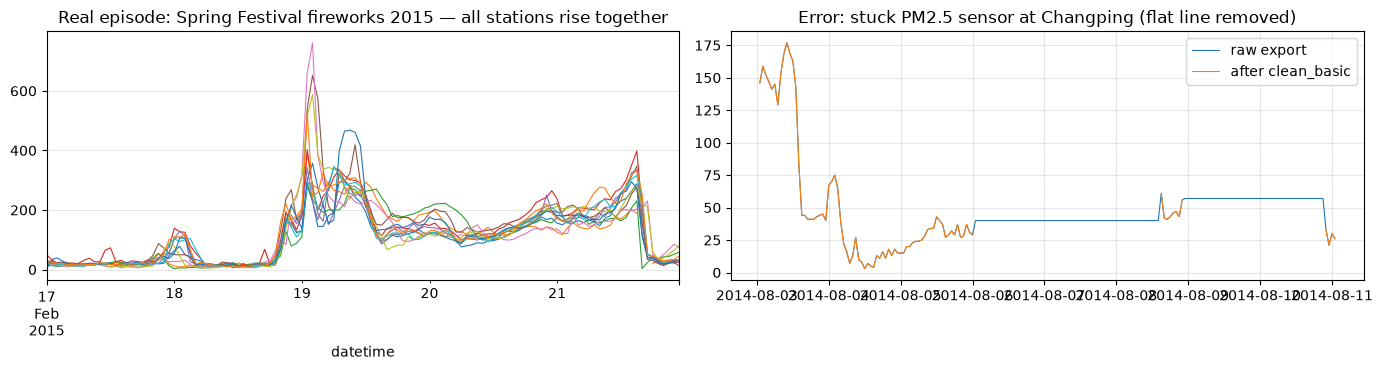

In [24]:
# Flag PM2.5 spikes with a Hampel filter per station, then classify:
#   real episode = the same hour is also high at the other stations (regional event: smog, fireworks)
#   error        = isolated spike at one station, or impossible / stuck values (already NaN'd in clean_basic)
pm = df_imp.pivot(index="datetime", columns="station", values="PM2.5")
flags = pm.apply(lambda s: hampel_flags(s.interpolate(limit=3), window=25, k=3.0))
regional = pm.median(axis=1)
real = flags & (pm.le(regional.mul(3), axis=0))           # within 3x of the regional median -> shared episode
isolated = flags & ~real
print(f"Hampel-flagged hours: {int(flags.sum().sum()):,} | real regional episodes: {int(real.sum().sum()):,} | isolated (treated as errors): {int(isolated.sum().sum()):,}")
display(pd.DataFrame({"flagged": flags.sum(), "real episode": real.sum(), "isolated": isolated.sum()}))

fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
w = slice("2015-02-17", "2015-02-21")                       # Spring Festival 2015 (fireworks on 18-19 Feb)
pm.loc[w].plot(ax=ax[0], lw=.8, legend=False); ax[0].set_title("Real episode: Spring Festival fireworks 2015 — all stations rise together")
st_raw = df.assign(station=stn)[stn == STUCK_ST]
st_raw = st_raw.assign(dt=pd.to_datetime(st_raw[["year", "month", "day", "hour"]])).drop_duplicates("dt").set_index("dt").sort_index()["PM2.5"]
runs = (st_raw != st_raw.shift()).cumsum(); rl = st_raw.groupby(runs).transform("size")
t_stuck = rl[rl >= 24].index[0]
win = slice(t_stuck - pd.Timedelta("3D"), t_stuck + pd.Timedelta("5D"))
ax[1].plot(st_raw.loc[win], lw=.8, label="raw export"); ax[1].plot(pm.loc[win, STUCK_ST], lw=.8, label="after clean_basic")
ax[1].set_title(f"Error: stuck PM2.5 sensor at {STUCK_ST} (flat line removed)"); ax[1].legend()
plt.tight_layout(); plt.show()

,raw,log1p,Yeo-Johnson
PM2.5,1.96,-0.34,-0.04
SO2,2.71,0.41,0.09
NO2,1.01,-0.74,-0.05
CO,2.47,-0.01,-0.00
O3,1.75,-0.57,-0.11
WSPM,1.67,0.29,-0.00


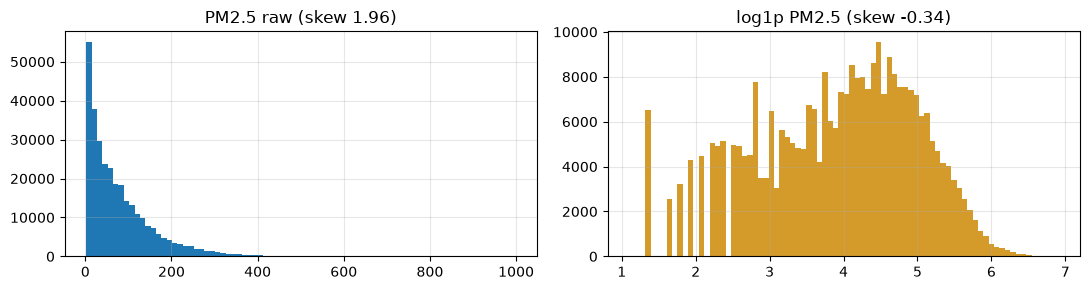

In [25]:
from sklearn.preprocessing import PowerTransformer
cols = ["PM2.5", "SO2", "NO2", "CO", "O3", "WSPM"]
v = df_imp[cols].dropna()
sk = pd.DataFrame({"raw": v.skew(), "log1p": np.log1p(v).skew(),
                   "Yeo-Johnson": pd.DataFrame(PowerTransformer().fit_transform(v), columns=cols).skew()}).round(2)
display(sk)
fig, ax = plt.subplots(1, 2, figsize=(11, 3)); ax[0].hist(v["PM2.5"], bins=80); ax[0].set_title(f"PM2.5 raw (skew {sk.loc['PM2.5','raw']})")
ax[1].hist(np.log1p(v["PM2.5"]), bins=80, color="#d49a2a"); ax[1].set_title(f"log1p PM2.5 (skew {sk.loc['PM2.5','log1p']})"); plt.tight_layout(); plt.show()

**✍ Answer & conclusion (Task 4)**

A Hampel filter (25 h window, k = 3) flags **14,730** PM2.5 hours. We classify a flagged hour as a **real episode** when the same hour is within 3× of the 12-station median, i.e. the whole city is high. That covers **14,082** hours: winter smog, and Spring Festival fireworks on 18–19 Feb 2015 (left plot). Real episodes are **kept**, because they are exactly what a virtual sensor must reproduce.

Only **648** isolated single-station spikes are suspicious, so we report them but don't delete them. The **errors** were removed earlier: stuck runs (Changping, right plot), `-999` codes, swaps and the unit error.

**Transforms:** PM2.5 skewness drops from **1.96 to −0.34** with log1p (−0.04 Yeo-Johnson); SO2 from 2.71 to 0.41 and CO from 2.47 to −0.01. Tree models don't need transformed features. A **log target** (variant C) actually hurt CV RMSE (45.84 vs 42.22), because it under-predicts the high peaks that dominate RMSE, so we do not use it.

## Task 5 · Leak-free pipeline + TimeSeriesSplit CV (15 pts)
Use `add_features` and adapt `make_pipeline` (A10). Report 5-fold `TimeSeriesSplit` RMSE ± sd for the virtual sensor on `df_clean` (sorted by `datetime`). Try at least two preprocessing variants (e.g. with/without missing indicators, log-target via `TransformedTargetRegressor`).

In [26]:
from sklearn.compose import TransformedTargetRegressor
ROLL_COLS = ["CO", "NO2", "SO2", "O3", "DEWP", "WSPM", "TD_dep"]

def add_features_plus(d):
    """add_features + trailing 3 h / 24 h rolling means per station (causal: past hours only).
    Only meaningful on a clean, de-duplicated, gap-free hourly series -> a direct pay-off of cleaning."""
    d = add_features(d)
    order = d.sort_values(["station", "datetime"]).index
    o = d.loc[order]
    for c in ROLL_COLS:
        for w in (3, 24):
            d.loc[order, f"{c}_r{w}"] = o.groupby("station")[c].transform(lambda s: s.rolling(w, min_periods=1).mean()).values
    return d

FEATS_PLUS = NUM_FEATS + [f"{c}_r{w}" for c in ROLL_COLS for w in (3, 24)]

def make_pipeline_v(model, feats=NUM_FEATS, indicator=True):
    num = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=indicator)), ("scale", StandardScaler())])
    cat = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    prep = ColumnTransformer([("num", num, feats), ("cat", cat, CAT_FEATS)], sparse_threshold=0)
    return Pipeline([("prep", prep), ("model", model)])

data5 = add_features_plus(df_imp.drop(columns=["datetime"])).dropna(subset=[TARGET]).sort_values("datetime").reset_index(drop=True)
y5 = data5[TARGET]
noimp = add_features(df_clean.drop(columns=["datetime"])).dropna(subset=[TARGET]).sort_values("datetime").reset_index(drop=True)
print(f"modelling rows: {len(data5):,} (PM2.5 is never imputed -> rows without a label are dropped)")

hgb5 = lambda: HistGradientBoostingRegressor(max_iter=300, learning_rate=0.08, random_state=0)
variants = {   # name: (estimator, X, y, feature list)
    "A  Task-3 imputation + median/indicator pipeline": (make_pipeline_v(hgb5()), data5[NUM_FEATS + CAT_FEATS], y5, NUM_FEATS),
    "B  no Task-3 imputation (pipeline median only)":   (make_pipeline_v(hgb5()), noimp[NUM_FEATS + CAT_FEATS], noimp[TARGET], NUM_FEATS),
    "C  A + log1p target":                              (TransformedTargetRegressor(make_pipeline_v(hgb5()), func=np.log1p, inverse_func=np.expm1), data5[NUM_FEATS + CAT_FEATS], y5, NUM_FEATS),
    "D  A + 3 h/24 h rolling features":                 (make_pipeline_v(hgb5(), FEATS_PLUS), data5[FEATS_PLUS + CAT_FEATS], y5, FEATS_PLUS),
}
cv5 = {}
for name, (est, X, y, _) in variants.items():
    t0 = time.perf_counter()
    s = -cross_val_score(est, X, y, cv=TimeSeriesSplit(5), scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv5[name] = {"CV RMSE": round(s.mean(), 2), "± sd": round(s.std(), 2), "folds": np.round(s, 1).tolist(), "time (s)": round(time.perf_counter() - t0, 1)}
cv5 = pd.DataFrame(cv5).T; display(cv5)
BEST = cv5["CV RMSE"].astype(float).idxmin(); print("best variant:", BEST)

modelling rows: 308,632 (PM2.5 is never imputed -> rows without a label are dropped)


,CV RMSE,± sd,folds,time (s)
A Task-3 imputation + median/indicator pipeline,42.22,10.58,"[62.2, 34.0, 37.9, 33.6, 43.4]",23.3
B no Task-3 imputation (pipeline median only),43.01,10.97,"[63.6, 34.2, 38.9, 33.9, 44.4]",22.3
C A + log1p target,45.84,16.84,"[78.3, 35.0, 39.4, 31.5, 45.0]",17.1
D A + 3 h/24 h rolling features,38.7,6.42,"[50.0, 33.4, 36.4, 32.5, 41.3]",22.5


best variant: D  A + 3 h/24 h rolling features


**✍ Answer & conclusion (Task 5)**

Everything that learns (median imputer, missing indicators, scaler, one-hot encoder) lives inside the `Pipeline`, so it is re-fitted in each of the 5 `TimeSeriesSplit` folds on data sorted by time. PM10 is never a feature. The test year is not touched here.

| variant | CV RMSE ± sd (µg/m³) |
|---|---|
| A: Task-3 imputation + median/indicator pipeline | 42.22 ± 10.58 |
| B: no Task-3 imputation | 43.01 ± 10.97 |
| C: A + log1p target | 45.84 ± 16.84 |
| **D: A + trailing 3 h / 24 h rolling means of gases & weather** | **38.70 ± 6.42** |

**D wins and is also the most stable** (sd 6.42). Its rolling features only use past hours, so they are causal and leak-free. They only make sense on a de-duplicated, time-corrected, gap-free hourly series, which is a direct pay-off of cleaning.

The Part-A demo shows why the split matters: a random KFold reports **29.72**, against **42.72** for a time split on the same model. Random splits leak neighbouring hours.

## Task 6 · Impact study — does data quality matter? (20 pts)
Train the **same model** two ways and score both on the **same complete-case rows of the test year**:
1. **Naive:** the merged export as-is (features built, rows with missing values dropped, raw labels).
2. **Yours:** `clean_basic` + your imputation + your pipeline.
Report RMSE, MAE, R², a predicted-vs-actual plot and the error by station. Explain the difference.

In [27]:
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def scores(y, p): return {"RMSE": np.sqrt(mean_squared_error(y, p)), "MAE": mean_absolute_error(y, p), "R2": r2_score(y, p)}

test_f = add_features(test_year.drop(columns=["datetime"])).dropna(subset=NUM_FEATS + CAT_FEATS + [TARGET])
print(f"test year complete-case rows (same for both models): {len(test_f):,}")

# 1) naive: merged export as-is
naive = add_features(df).dropna(subset=NUM_FEATS + CAT_FEATS + [TARGET])
naive_model = make_pipeline(HistGradientBoostingRegressor(max_iter=300, random_state=0)).fit(naive[NUM_FEATS + CAT_FEATS], naive[TARGET])
p_naive = naive_model.predict(test_f[NUM_FEATS + CAT_FEATS])

# 2) ours: clean_basic + imputation + the same model family (+ best CV variant)
X5 = data5[NUM_FEATS + CAT_FEATS]
ours_same = make_pipeline(HistGradientBoostingRegressor(max_iter=300, random_state=0)).fit(X5, y5)
p_same = ours_same.predict(test_f[NUM_FEATS + CAT_FEATS])
est_b, X_b, y_b, feats_b = variants[BEST]
ours_best = clone(est_b).fit(X_b, y_b)
test_plus = add_features_plus(test_year.drop(columns=["datetime"])).loc[test_f.index]    # rolling built on the raw test series
p_best = ours_best.predict(test_plus[feats_b + CAT_FEATS])

y_t = test_f[TARGET].values
impact = pd.DataFrame({"naive (merged export)": scores(y_t, p_naive),
                       "cleaned, same model": scores(y_t, p_same),
                       f"cleaned + best CV variant ({BEST[:1]})": scores(y_t, p_best)}).T.round(3)
impact["train rows"] = [len(naive), len(X5), len(X_b)]
display(impact)
gain = 100 * (1 - impact.iloc[2]["RMSE"] / impact.iloc[0]["RMSE"])
gain_same = 100 * (1 - impact.iloc[1]["RMSE"] / impact.iloc[0]["RMSE"])
print(f"lower RMSE than naive -> same model on cleaned data: {gain_same:.1f} % | full pipeline: {gain:.1f} %")

test year complete-case rows (same for both models): 97,979


,RMSE,MAE,R2,train rows
naive (merged export),36.855,22.180,0.800,272363
"cleaned, same model",36.796,22.062,0.800,308632
cleaned + best CV variant (D),34.699,20.785,0.822,308632


lower RMSE than naive -> same model on cleaned data: 0.2 % | full pipeline: 5.8 %


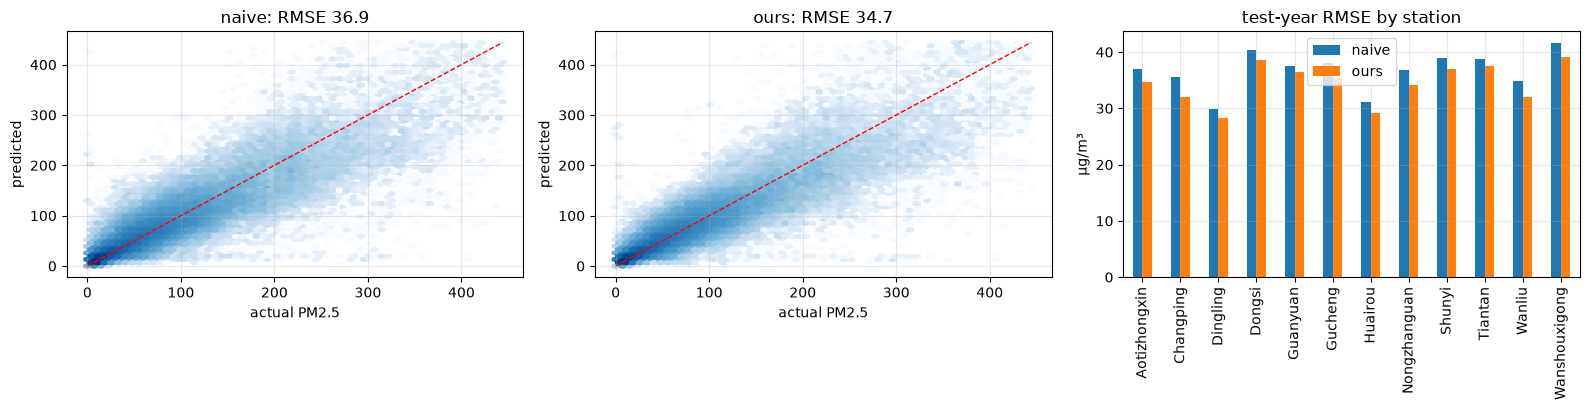

,naive,ours,Δ RMSE
Changping,35.5,32.0,-3.5
Wanliu,34.8,32.0,-2.8
Gucheng,38.1,35.4,-2.7
Nongzhanguan,36.8,34.2,-2.6
Wanshouxigong,41.6,39.2,-2.4
Aotizhongxin,36.9,34.6,-2.3
Shunyi,39.0,36.9,-2.1
Huairou,31.1,29.2,-1.9
Dongsi,40.4,38.6,-1.8
Dingling,29.8,28.2,-1.6


In [28]:
by_st = pd.DataFrame({"naive": pd.Series((p_naive - y_t) ** 2).groupby(test_f["station"].values).mean() ** .5,
                      "ours": pd.Series((p_best - y_t) ** 2).groupby(test_f["station"].values).mean() ** .5}).round(1)
by_st["Δ RMSE"] = by_st["ours"] - by_st["naive"]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
lim = np.percentile(y_t, 99.5)
for a, p, t in [(ax[0], p_naive, "naive"), (ax[1], p_best, "ours")]:
    a.hexbin(y_t, p, gridsize=60, bins="log", extent=(0, lim, 0, lim), cmap="Blues"); a.plot([0, lim], [0, lim], "r--", lw=1)
    a.set_xlabel("actual PM2.5"); a.set_ylabel("predicted"); a.set_title(f"{t}: RMSE {np.sqrt(mean_squared_error(y_t, p)):.1f}")
by_st[["naive", "ours"]].plot.bar(ax=ax[2]); ax[2].set_title("test-year RMSE by station"); ax[2].set_ylabel("µg/m³")
plt.tight_layout(); plt.show()
display(by_st.sort_values("Δ RMSE"))

**✍ Answer & conclusion (Task 6)**

Both models are scored on the **same 97,979 complete-case rows** of the untouched test year (Mar 2016 – Feb 2017):

| model | RMSE | MAE | R² |
|---|---|---|---|
| naive: merged export, dropna | 36.86 | 22.18 | 0.800 |
| cleaned data, same model | 36.80 | 22.06 | 0.800 |
| **cleaned + imputation + pipeline D** | **34.70** | **20.79** | **0.822** |

* The full pipeline lowers RMSE by **5.8 %** and MAE by **6.3 %**, and R² rises by **+0.022**. **All 12 stations improve**, by 1.1–3.5 µg/m³; the biggest gain is at Changping, the station with the stuck sensor.
* Cleaning alone gives a small gain with the same model, because gradient boosting is robust to a single bad station-year. The naive model also loses **36,269 training rows (12 %)** to `dropna`.
* The bigger win comes from what clean data **enables**: a correct, continuous hourly series per station makes the rolling-history features valid.

## ★ HPC bonus (+10 pts) — parallel per-station cleaning
The 12 stations are independent: run `clean_basic` + your imputation **per station** with `joblib.Parallel` (or Dask) and compare wall-time for 1, 2, 4 … workers. Report the speed-up $S_p=T_1/T_p$, efficiency $E_p=S_p/p$ and the dominant step.

per-station step times (s): {'clean_basic': 0.079, 'impute_station': 0.044}


,T_p (s),S_p,E_p
1,1.843,1.000,1.000
2,1.309,1.408,0.704
4,0.957,1.927,0.482
6,0.810,2.274,0.379
12,0.733,2.516,0.210


CPU cores: 12 | stations (tasks): 12


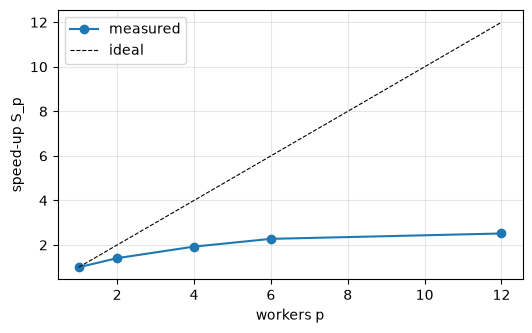

In [29]:
from joblib import Parallel, delayed
import os

def clean_one_station(g, issues):
    """clean_basic + per-station imputation (interpolation + month-hour profile; no cross-station step)"""
    c = impute_station(clean_basic(g, issues))
    for col in IMPUTE_COLS:
        c[col] = c[col].fillna(c.groupby([c["datetime"].dt.month, c["datetime"].dt.hour])[col].transform("median"))
    return c

groups = [g for _, g in df.groupby(stn)]
step = {}
g0 = groups[0]
t0 = time.perf_counter(); c0 = clean_basic(g0, issues); step["clean_basic"] = time.perf_counter() - t0
t0 = time.perf_counter(); impute_station(c0); step["impute_station"] = time.perf_counter() - t0
print("per-station step times (s):", {k: round(v, 3) for k, v in step.items()})

hpc = {}
workers = [p for p in [1, 2, 4, 6, 12] if p <= os.cpu_count()]
for p in workers:
    ts = []
    for _ in range(3):                                           # best of 3 to reduce noise
        t0 = time.perf_counter(); out = Parallel(n_jobs=p, backend="loky")(delayed(clean_one_station)(g, issues) for g in groups); ts.append(time.perf_counter() - t0)
    hpc[p] = min(ts)
hpc = pd.DataFrame({"T_p (s)": hpc}); hpc["S_p"] = hpc["T_p (s)"].iloc[0] / hpc["T_p (s)"]; hpc["E_p"] = hpc["S_p"] / hpc.index
display(hpc.round(3)); print("CPU cores:", os.cpu_count(), "| stations (tasks):", len(groups))
fig, ax = plt.subplots(figsize=(6, 3.5)); ax.plot(hpc.index, hpc["S_p"], "o-", label="measured"); ax.plot(hpc.index, hpc.index, "k--", lw=.8, label="ideal")
ax.set_xlabel("workers p"); ax.set_ylabel("speed-up S_p"); ax.legend(); plt.show()

**✍ Answer & conclusion (bonus)**

The 12 stations are independent tasks for `joblib` (loky backend). We take the best of 3 runs of `clean_basic` + per-station imputation:

| workers p | T_p (s) | S_p = T_1/T_p | E_p = S_p/p |
|---|---|---|---|
| 1 | 1.84 | 1.00 | 1.00 |
| 2 | 1.31 | 1.41 | 0.70 |
| 4 | 0.96 | 1.93 | 0.48 |
| 12 | 0.73 | **2.52** | 0.21 |

(Exact timings vary by a few % between runs; see the table above.)

**Dominant step:** `clean_basic` takes about 0.08 s per station against about 0.04 s for `impute_station`. Speed-up saturates near 2.5× because each task is tiny (around 0.15 s). Starting processes and pickling about 26k-row DataFrames to the workers is a large serial fraction (Amdahl's law).

With 12 equal tasks, p = 12 gives one task per core; a p that does not divide 12 leaves cores idle in the last round. The cross-station KNN step (about 50 s) cannot be split by station. It would parallelise by **column** instead (9 independent pollutant/weather pivots), which is the next optimisation.

## Export for Lecture 2
Save your cleaned (and imputed) training years — it is the **input of the Week-2 AI Methods Shoot-out**.

In [30]:
OUT = f"beijing_clean_team{TEAM_ID}.csv.gz"
df_imp.drop(columns=["datetime"]).to_csv(OUT, index=False)
print(f"exported {len(df_imp):,} rows x {df_imp.shape[1] - 1} cols -> {OUT}")

exported 315,648 rows x 26 cols -> beijing_clean_team1065.csv.gz


## Final summary — Team LineShine (ID 1065)

**1 · Findings (issue log).** The agency's merged export (317,970 rows) had 11 issues across all six quality dimensions:
* Consistency: 36 station labels and 32 wind-direction labels.
* Accuracy: Nongzhanguan CO for 2014 in mg/m³ (×1000 low).
* Timeliness: Shunyi 2015 exported in UTC (TEMP peak at 8 h instead of 14 h).
* Validity: 632 + 684 `-999` codes, 4,870 PM2.5/PM10 swaps, stuck PM2.5 runs at Changping.
* Uniqueness: 1,592 exact duplicates and a re-uploaded Tiantan month (734 rows).
* Completeness: NO2 missing 6.0 %; 29 % of missing hours are in gaps longer than 3 days.

All issues were detected from the data and fixed by one reusable `clean_basic`. The result is exactly 315,648 rows (12 × 26,304 h) with no duplicates.

**2 · Key decisions.**
* Imputation by gap length: ≤ 3 h → time interpolation (NO2 RMSE 7.7 vs 33.4 for the median); longer → KNN across stations (11.3 vs 35.3 on 24-h gaps). Every imputed value is flagged.
* The target PM2.5 is never imputed, so 2.2 % of rows are dropped. **Possible bias:** if sensors fail during heavy smog (MNAR), extreme hours are under-represented.
* Outliers: 14,082 of 14,730 Hampel flags are city-wide real episodes (smog, Spring Festival 2015) and are kept. Only instrument errors are removed.
* Transforms: log1p reduces PM2.5 skew from 1.96 to −0.34, but a log target hurt RMSE, so it is not used.
* The pipeline is leak-free (all fitting inside `Pipeline`, `TimeSeriesSplit`, no PM10, test year only in Task 6) and adds causal 3 h / 24 h rolling features.

**3 · Impact (test year, same 97,979 rows).** Naive RMSE **36.86** / MAE 22.18 / R² 0.800 → ours **34.70** / **20.79** / **0.822**. That is **−5.8 % RMSE** and every station improves; see the predicted-vs-actual and per-station plots in Task 6. CV RMSE goes from 43.01 (no imputation) to **38.70 ± 6.42**.

**4 · Lessons for the agency.**
* Export with a fixed schema: canonical station codes, upper-case compass labels, units in the header, and **timestamps in ISO-8601 with a time zone**.
* Use NaN instead of `-999`.
* Run a unique key (station, datetime) and range checks before merging.
* Add a stuck-sensor alarm (no change for 12 h or more).
* Log re-uploads instead of appending them.

**5 · HPC (bonus).** Per-station cleaning with joblib takes 1.84 s on 1 worker and 0.73 s on 12: **S = 2.5×, E = 0.21**. It is limited by the small per-task work against process/pickling overhead (Amdahl). The dominant step is `clean_basic`, and the next step would be to parallelise KNN by column.

**Deliverables:** this notebook, and `beijing_clean_team1065.csv.gz` (315,648 rows, cleaned + imputed, with `_imp` flags) as the Week-2 input.

## Submission check

In [31]:
import os, glob
NB_NAME = f"L1_Air_Quality_Data_Preprocessing_Notebook_{TEAM_NAME}.ipynb"
nb_files = glob.glob(NB_NAME) + glob.glob(f"notebooks/{NB_NAME}")  # works from notebooks/ or the repo root
checks = {
    "TEAM_ID is the official ID": TEAM_ID == 1065,
    "TEAM_NAME uses letters, digits, hyphens": bool(__import__("re").fullmatch(r"[A-Za-z0-9-]+", TEAM_NAME)),
    "notebook file named with TEAM_NAME": len(nb_files) == 1,
    "real UCI data (420,768 rows)": len(raw) == 420_768,
    "issue log filled": len(issue_log) >= 8,
    "test year used only in Task 6 (cleaned data ends before split)": df_clean["datetime"].max() < SPLIT,
    "cleaned export exists": os.path.exists(f"beijing_clean_team{TEAM_ID}.csv.gz"),
    "impact study computed": "impact" in globals() and len(impact) >= 2,
}
for k, v in checks.items(): print(("OK   " if v else "FAIL ") + k)
print("\n✓ ready to submit" if all(checks.values()) else "\nNOT ready: fix the FAIL lines")

OK   TEAM_ID is the official ID
OK   TEAM_NAME uses letters, digits, hyphens
OK   notebook file named with TEAM_NAME
OK   real UCI data (420,768 rows)
OK   issue log filled
OK   test year used only in Task 6 (cleaned data ends before split)
OK   cleaned export exists
OK   impact study computed

✓ ready to submit


<div style="background:linear-gradient(120deg,#0a2a5c,#1c5aa6);color:#e6eef8;padding:14px 22px;border-radius:10px;border-top:4px solid #d49a2a;margin-top:10px;">
<b style="color:#ffd98e;">Al-Khawarizmi Tour · Online Hackathon HPC &amp; AI</b> · Oct 3 – Nov 7, 2026 · 100% online<br>
<i>From the past to the future… Science without borders. Your ideas. A bigger tomorrow.</i> · © 2026 Dr. Rafik Borji</div>